In [3]:

import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.sparse import coo_matrix, csc_matrix
from numbers import Number
import numpy as np
import scipy
from scipy.sparse import csc_matrix, dia_matrix
from typing import Literal, Tuple, Callable, List
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import RectBivariateSpline
import linear_solver
from matplotlib import colors
from matplotlib.patches import Rectangle

np.set_printoptions(linewidth=np.inf)
np.set_printoptions(precision=3, suppress=True)

In [206]:
class NavierStokesSolver:
    
    scheme              : Literal["central_difference", "upwind", "hybrid"]

    L_x                 : float
    L_y                 : float
    n_rows              : int
    n_cols              : int
    phi_B               : float
    gamma               : float
    error               : float
    
    # if u is None
    u_B                 : dict
    v_B                 : dict
    B                   : dict
    
    kinematic_viscosity : float
    u_char              : float
    mass_density        : float
    Re                  : float
    
    alpha_m             : float
    alpha_p             : float
    
    A                   : dict
    b                   : dict
    x                   : dict
    
    _constructor_args_  : dict
    
    A_diag              : dia_matrix
    
    obstacles           : Tuple[Tuple]
    
    def __init__(
        
        self, 
        scheme: Literal["central_difference", "upwind", "hybrid"] = "central_difference",
        L_x         : float = 1,
        L_y         : float = 1,
        n_rows      : int = 50,
        n_cols      : int = 50,
        gamma       : float = 1,
        u           : Tuple[Number | Callable] | None = None,
        
        phi_B       : Tuple = (None, None, None, None),
        u_B         : Tuple = (None, None, None, None),
        v_B         : Tuple = (None, None, None, None),

        kinematic_viscosity : float = None,
        Re                  : float = 100,
        u_char              : float = 1,
        mass_density        : float = 1,
        alpha_m             : float = 0.7,
        alpha_p             : float = 0.3,
        
        obstacle_coords     : List[Tuple[Tuple]] = None
        
        ):
        
        self._constructor_args_ = {key: val for key, val in locals().items() if key != 'self'}
        
        self.L_x        = L_x
        self.L_y        = L_y
        self.n_rows     = n_rows
        self.n_cols     = n_cols
        self.delta_x    = self.L_x / self.n_cols
        self.delta_y    = self.L_y / self.n_rows
        self.has_vel    = u is not None
        self.scheme     = scheme
        self.alpha_m    = alpha_m
        self.alpha_p    = alpha_p
        self.gamma      = gamma
        
        self.A = { '\phi': None, 'm': None, "p\'": None }
        self.b = { '\phi': None, 'u': None, 'v': None, "p\'": None }
        self.x = { '\phi': None, 'u': None, 'v': None, 'u_f': None, 'v_f': None, 's': None, "p\'": None,"p": None }
        self.A_diag = dia_matrix((self.n_rows * self.n_cols, self.n_rows * self.n_cols))

        self.u_B        = {'e': u_B[0], 'w': u_B[1], 'n': u_B[2], 's': u_B[3]}
        self.v_B        = {'e': v_B[0], 'w': v_B[1], 'n': v_B[2], 's': v_B[3]}
        self.phi_B      = {'e': phi_B[0], 'w': phi_B[1], 'n': phi_B[2], 's': phi_B[3]}
        self.B          = { 'u': self.u_B, 'v': self.v_B, '\phi': self.phi_B }
        
        self.x['u_f']   = np.zeros((self.n_rows + 2, self.n_cols + 1))
        self.x['v_f']   = np.zeros((self.n_rows + 1, self.n_cols + 2))        
        self.x['u']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['v']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        

        
        self.x['s']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        
        self.boundary_mask                  = np.zeros((self.n_rows + 2, self.n_cols + 2)).astype(bool)
        self.boundary_mask[[0, -1], :]      = True
        self.boundary_mask[:, [0, -1]]      = True
        self.interior_mask                  = ~self.boundary_mask

        self.obstacle_mask                  = np.zeros((self.n_rows + 2, self.n_cols + 2)).astype(bool)
        self.obstacles = []
        if obstacle_coords:
            for obs in obstacle_coords:
                (x1, y1), (x2, y2) = self._obstacle_coords_(obs) 
                self.obstacles.append(((x1, y1), (x2, y2)))
                self.obstacle_mask[y1:y2+1, x1:x2+1] = True

        self.boundary_mask |= self.obstacle_mask
        
        self.fluid_mask     = ~self.boundary_mask

          

        self.e_nbr_mask     = self.fluid_mask & np.roll(self.fluid_mask, 1, 1)
        self.w_nbr_mask     = self.fluid_mask & np.roll(self.fluid_mask, -1, 1)
        self.n_nbr_mask     = self.fluid_mask & np.roll(self.fluid_mask, -1, 0)
        self.s_nbr_mask     = self.fluid_mask & np.roll(self.fluid_mask, 1, 0)

        self.has_e_nbr_mask = self.fluid_mask & np.roll(self.fluid_mask, -1, 1)
        self.has_w_nbr_mask = self.fluid_mask & np.roll(self.fluid_mask, 1, 1)
        self.has_n_nbr_mask = self.fluid_mask & np.roll(self.fluid_mask, 1, 0)
        self.has_s_nbr_mask = self.fluid_mask & np.roll(self.fluid_mask, -1, 0)
        
        self.e_bnd_mask     = self.boundary_mask & np.roll(self.fluid_mask, 1, 1)
        self.w_bnd_mask     = self.boundary_mask & np.roll(self.fluid_mask, -1, 1)
        self.n_bnd_mask     = self.boundary_mask & np.roll(self.fluid_mask, -1, 0)
        self.s_bnd_mask     = self.boundary_mask & np.roll(self.fluid_mask, 1, 0)
        
        self.has_e_bnd_mask = self.fluid_mask & np.roll(self.boundary_mask, -1, 1)
        self.has_w_bnd_mask = self.fluid_mask & np.roll(self.boundary_mask, 1, 1)
        self.has_n_bnd_mask = self.fluid_mask & np.roll(self.boundary_mask, 1, 0)
        self.has_s_bnd_mask = self.fluid_mask & np.roll(self.boundary_mask, -1, 0)
        
        
        # hardcoded fornow, to be updated with user input on subsequent releases
        # all non-src walls are assumed to be neumann with zero gradient (ex: insulators)
        # all src-walls are dirichlet defined by the client
        self.dirichlet_bnd = {
            'm':{}, 'p\'': {}, '\phi': {}
        }

        phi_dir = np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool)
        phi_dir[[0, -1], :] = True
        phi_dir[:, [0, -1]] = True

        self.dirichlet_bnd['\phi'] = {
                'all': phi_dir,
                'e': phi_dir & np.roll(self.fluid_mask, 1, 1),
                'w': phi_dir & np.roll(self.fluid_mask, -1, 1),
                'n': phi_dir & np.roll(self.fluid_mask, -1, 0),
                's': phi_dir & np.roll(self.fluid_mask, 1, 0)
            }


        self.dirichlet_bnd['m'] = {
                'all': self.boundary_mask,
                'e': self.boundary_mask & np.roll(self.fluid_mask, 1, 1),
                'w': self.boundary_mask & np.roll(self.fluid_mask, -1, 1),
                'n': self.boundary_mask & np.roll(self.fluid_mask, -1, 0),
                's': self.boundary_mask & np.roll(self.fluid_mask, 1, 0)
            }
        self.dirichlet_bnd['p\''] = {
                'all': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
                'e': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
                'w': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
                'n': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
                's': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool)
        }

        self.neumann_bnd = {
            'm':{},  'p\'': {}, '\phi': {}
        }

        phi_neum_e = self.obstacle_mask & np.roll(self.fluid_mask, -1, 1)
        phi_neum_w = self.obstacle_mask & np.roll(self.fluid_mask, 1, 1)
        phi_neum_n = self.obstacle_mask & np.roll(self.fluid_mask, 1, 0)
        phi_neum_s = self.obstacle_mask & np.roll(self.fluid_mask, -1, 0)
        phi_neum = phi_neum_e | phi_neum_w | phi_neum_n | phi_neum_s

        self.neumann_bnd['\phi'] = {
                'all': phi_neum,
                'e': phi_neum_e,
                'w': phi_neum_w,
                'n': phi_neum_n,
                's': phi_neum_s
            }
        
        self.neumann_bnd['m'] = {
            'all': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
            'e': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
            'w': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
            'n': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool),
            's': np.zeros((self.n_rows +2, self.n_cols+2)).astype(bool)
        }

        self.neumann_bnd['p\''] = {
                'all': self.boundary_mask,
                'e': self.boundary_mask & np.roll(self.fluid_mask, 1, 1),
                'w': self.boundary_mask & np.roll(self.fluid_mask, -1, 1),
                'n': self.boundary_mask & np.roll(self.fluid_mask, -1, 0),
                's': self.boundary_mask & np.roll(self.fluid_mask, 1, 0)
            }
        

        for k, v in self.B.items():
            if v['e'] is None:
                self.dirichlet_bnd[k if k not in ['u', 'v'] else 'm']['e'][:, -1] = False
                self.neumann_bnd[k if k not in ['u', 'v'] else 'm']['e'][:, -1] = True
            if v['w'] is None:
                self.dirichlet_bnd[k if k not in ['u', 'v'] else 'm']['w'][:, 0] = False
                self.neumann_bnd[k if k not in ['u', 'v'] else 'm']['w'][:, 0] = True
            if v['n'] is None:
                self.dirichlet_bnd[k if k not in ['u', 'v'] else 'm']['n'][0, :] = False
                self.neumann_bnd[k if k not in ['u', 'v'] else 'm']['n'][0, :] = True
            if v['s'] is None:
                self.dirichlet_bnd[k if k not in ['u', 'v'] else 'm']['s'][-1, :] = False
                self.neumann_bnd[k if k not in ['u', 'v'] else 'm']['s'][-1, :] = True
                        

        
        self.e_nbr_face_mask = self.e_nbr_mask[:, 1:]
        self.w_nbr_face_mask = self.w_nbr_mask[:, :-1] # duplicate
        self.n_nbr_face_mask = self.n_nbr_mask[:-1, :]
        self.s_nbr_face_mask = self.s_nbr_mask[1:, :] # duplicate

        self.u_f_fluid_mask = self.e_nbr_face_mask
        self.v_f_fluid_mask = self.n_nbr_face_mask


        self.f_e_mask = (self.has_e_nbr_mask | self.has_e_bnd_mask)[:, :-1]
        self.f_w_mask = (self.has_w_nbr_mask | self.has_w_bnd_mask)[:, 1:]
        self.f_n_mask = (self.has_n_nbr_mask | self.has_n_bnd_mask)[1:, :]
        self.f_s_mask = (self.has_s_nbr_mask | self.has_s_bnd_mask)[:-1, :]
        

        
        if u is None: # We need to solve for velocity fields
   
            
            assert(bool(kinematic_viscosity) != bool(Re))
            
            self.L_char                 = np.sqrt(L_x**2 + L_y**2)
            self.u_char                 = u_char
            self.kinematic_viscosity    = kinematic_viscosity if kinematic_viscosity else self.u_char * self.L_char / Re
            self.mass_density           = mass_density
            self.Re                     = Re if Re else self.u_char * self.L_char / kinematic_viscosity
            self.gamma                  = 1/self.Re
            
            # set velocity boundary conditions
            
            self.x['u_f'][:, self.n_cols]       = self.B['u']['e'] if self.B['u']['e'] is not None else 0
            self.x['u_f'][:, 0]                 = self.B['u']['w'] if self.B['u']['w'] is not None else 0
            self.x['u_f'][0, :]                 = self.B['u']['n'] if self.B['u']['n'] is not None else 0
            self.x['u_f'][self.n_rows + 1, :]   = self.B['u']['s'] if self.B['u']['s'] is not None else 0
            
            self.x['v_f'][:, self.n_cols + 1]   = self.B['v']['e'] if self.B['v']['e'] is not None else 0
            self.x['v_f'][:, 0]                 = self.B['v']['w'] if self.B['v']['w'] is not None else 0
            self.x['v_f'][0, :]                 = self.B['v']['n'] if self.B['v']['n'] is not None else 0
            self.x['v_f'][self.n_rows, :]       = self.B['v']['s'] if self.B['v']['s'] is not None else 0
            
            

            
        else: # Use the known velocityy field to construct a matrix storing face velocities (giving convective link coefficients)
            
            uxf = lambda i, j : u[0] if isinstance(u[0], int) else u[0](j * self.delta_x, ((self.n_rows + 1) - i - 1)*self.delta_y)   
            uyf = lambda i, j : u[1] if isinstance(u[1], int) else u[1](j * self.delta_x, ((self.n_rows + 1) - i - 1)*self.delta_y) 
              
            for i in range(self.n_rows + 2):
                for j in range(self.n_cols+1):
                    self.x['u_f'][i,j] = uxf(i, j)
            for i in range(self.n_rows + 1):
                for j in range(self.n_cols + 2):
                    self.x['v_f'][i,j] = uyf(i, j)
            
            for i in range(1, self.n_rows+1):
                for j in range(1, self.n_cols + 1):
                    self.x['u'][i,j] = uxf(i+ self.delta_y, j + self.delta_x)
                    self.x['v'][i,j] = uyf(i+ self.delta_y, j + self.delta_x)
                    
            self.x['s'] = np.sqrt(self.x['u']**2 + self.x['v']**2)

                  
        # diffusive link coefficients
        self.D = {
            'w': self._area_('w') * self.gamma / self.delta_y,
            'e': self._area_('e') * self.gamma / self.delta_y,
            'n': self._area_('n') * self.gamma / self.delta_x,
            's': self._area_('s') * self.gamma / self.delta_x,
        }
        
        self.A['\phi'] = {
                'p': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'e': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'w': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                's': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'n': np.zeros((self.n_rows + 2, self.n_cols + 2)),
            }
        
        # set the solution boundary (Dirichlet)
        
        self.x['\phi']                                       = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['\phi'][:, self.n_cols + 1]                   = self.B['\phi']['e'] if self.B['\phi']['e'] is not None else 0
        self.x['\phi'][:, 0]                                 = self.B['\phi']['w'] if self.B['\phi']['w'] is not None else 0
        self.x['\phi'][0, 1: self.n_cols + 1]                = self.B['\phi']['n'] if self.B['\phi']['n'] is not None else 0
        self.x['\phi'][self.n_rows + 1, 1: self.n_cols + 1]  = self.B['\phi']['s'] if self.B['\phi']['s'] is not None else 0
        self.b['\phi']                                       = np.zeros((self.n_rows + 2,  self.n_cols + 2))

        if u is None: # Set the link_coefficient matrices and guess the solutions
            
            # guess the velocity field solution
            self.A['m'] = {
                'p': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'e': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'w': np.ones((self.n_rows + 2, self.n_cols + 2)),
                's': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'n': np.ones((self.n_rows + 2, self.n_cols + 2)),
            }
            self.A['p\''] = {
                'p': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'e': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'w': np.ones((self.n_rows + 2, self.n_cols + 2)),
                's': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'n': np.ones((self.n_rows + 2, self.n_cols + 2)),
            }

            self.x['p']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.x["p\'"]   = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            
            self.b['u']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.b['v']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.b["p\'"]   = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            
            # setting the solution boundary
            
            self.x['u'][:, self.n_cols + 1]                         = self.B['u']['e'] if self.B['u']['e'] is not None else 0
            self.x['u'][:, 0]                                       = self.B['u']['w'] if self.B['u']['w'] is not None else 0
            self.x['u'][0, 1: self.n_cols + 1]                      = self.B['u']['n'] if self.B['u']['n'] is not None else 0
            self.x['u'][self.n_rows +1, 1: self.n_cols + 1]         = self.B['u']['s'] if self.B['u']['s'] is not None else 0
            
            self.x['v'][:, self.n_cols + 1]                         = self.B['v']['e'] if self.B['v']['e'] is not None else 0
            self.x['v'][:, 0]                                       = self.B['v']['w'] if self.B['v']['w'] is not None else 0
            self.x['v'][0, 1:self.n_cols + 1]                       = self.B['v']['n'] if self.B['v']['n'] is not None else 0
            self.x['v'][self.n_rows + 1, 1: self.n_cols + 1]        = self.B['v']['s'] if self.B['v']['s'] is not None else 0
            

            
            
            # setting the pressure link coefficients
            

    def _obstacle_coords_(self, obstacle_coords):
        # Obstacle coordinates in real-world space
        (x1_real, y1_real), (x2_real, y2_real) = obstacle_coords
        
        x1 = x1_real/self.L_x
        x2 = x2_real/self.L_x
        y1 = y1_real/self.L_y
        y2 = y2_real/self.L_y
        # Map real-world coordinates to grid indices
        pixel_x1 = int(x1 * self.n_cols)  + 1
        pixel_y1 = (self.n_rows - 1) - int(y2*self.n_rows) + 1
        pixel_x2 = int(x2 * self.n_cols)  + 1
        pixel_y2 = (self.n_rows - 1) - int(y1*self.n_rows) + 1
        
        return (pixel_x1, pixel_y1), (pixel_x2, pixel_y2)
    
    def import_params(self, u, v, u_f, v_f, p):
        
        
        self.x['u'] = RectBivariateSpline(np.linspace(0, 1, u.shape[0]), np.linspace(0, 1, u.shape[1]), u)(
            np.linspace(0, 1, self.n_rows+2), np.linspace(0, 1, self.n_cols+2))
        self.x['u_f'] = RectBivariateSpline(np.linspace(0, 1, u_f.shape[0]), np.linspace(0, 1, u_f.shape[1]), u_f)(
            np.linspace(0, 1, self.n_rows+2), np.linspace(0, 1, self.n_cols+1))
        self.x['v'] = RectBivariateSpline(np.linspace(0, 1, v.shape[0]), np.linspace(0, 1, v.shape[1]), v)(
            np.linspace(0, 1, self.n_rows+2), np.linspace(0, 1, self.n_cols+2))
        self.x['v_f'] = RectBivariateSpline(np.linspace(0, 1, v_f.shape[0]), np.linspace(0, 1, v_f.shape[1]), v_f)(
            np.linspace(0, 1, self.n_rows+1), np.linspace(0, 1, self.n_cols+2))
        self.x['p'] = RectBivariateSpline(np.linspace(0, 1, p.shape[0]), np.linspace(0, 1, p.shape[1]), p)(
            np.linspace(0, 1, self.n_rows+2), np.linspace(0, 1, self.n_cols+2))
        
        
        self.x['u_f'][0, :]                 = self.B['u']['n']
        self.x['u_f'][self.n_rows + 1, :]   = self.B['u']['s']
        self.x['u_f'][:, self.n_cols]       = self.B['u']['e']
        self.x['u_f'][:, 0]                 = self.B['u']['w']
        
        self.x['v_f'][0, :]                 = self.B['v']['n']
        self.x['v_f'][self.n_rows, :]       = self.B['v']['s']
        self.x['v_f'][:, self.n_cols + 1]   = self.B['v']['e']
        self.x['v_f'][:, 0]                 = self.B['v']['w']
        
    def solve(self, objective: Literal['\phi', 'm'] ='\phi', solveSparse=True, tolerance=0.01, max_iter=10_000, threshold=1e-3):
        
        if objective == '\phi':
            self._construct_problem_(objective='\phi')
            x =  self._solve_jacobi_(objective='\phi', tolerance=tolerance, max_iter=max_iter) if not solveSparse else self._solve_sparse_(objective='\phi')
            self._set_noflux_phi_()
            return x

        # no velocity field given, must first solve three separate FVM problems
        # one for u, v and p
        # and only then can the problem for \phi

        rmse = np.inf
        i = 0
  
        while rmse > threshold:

            u_prev = self.x['u'].copy()
            v_prev = self.x['v'].copy()
            
            self._construct_problem_(objective='m')
            
            self._solve_sparse_(objective='u') if solveSparse else self._solve_jacobi_(objective='u', tolerance=tolerance, max_iter=max_iter)
            self._solve_sparse_(objective='v') if solveSparse else self._solve_jacobi_(objective='v', tolerance=tolerance, max_iter=max_iter)
            

            self._interp_face_v_()
            self._construct_problem_(objective="p\'")
            self._solve_sparse_(objective="p\'") if solveSparse else self._solve_jacobi_(objective='p\'', tolerance=tolerance, max_iter=max_iter)
            
            
            self._correct_p_()
            self._correct_cell_v_()
            self._correct_face_v_()
            
            self.x['s'] = np.sqrt(self.x['u']**2 + self.x['v']**2)
            
            p_RMSE = np.sqrt(np.mean(np.square(self.x['p\''])))
            u_RMSE = np.sqrt(np.mean(np.square(self.x['u'] - u_prev)))
            v_RMSE = np.sqrt(np.mean(np.square(self.x['v'] - v_prev)))
            
            rmse = u_RMSE + v_RMSE + p_RMSE
            self.error = rmse
            print(f"\rIteration: {i}, u_RMSE: {u_RMSE:.3e}, v_RMSE: {v_RMSE:.3e}, p'_RMSE: {p_RMSE:.3e}", sep='', end='')

            
            i+=1
        
        print(f"\nFinished with total error {rmse}")
        return self.x['u'], u_RMSE, self.x['v'], v_RMSE, self.x['p'], p_RMSE
            
    def plot(self, 
             objective          : Literal['\phi', 'u', 'v', 'p']=None, 
             levels             : int = 40, 
             name               : str = None, 
             save               : bool = False,
             v_field_str        : Tuple[str, str] = None, 
             figsize            : int = 5,  
             streamlines        : float = 1.5
             ):
        
        core = self.x[objective][1:-1, 1:-1][::-1] if objective else None
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(2 * figsize if objective and streamlines else int(1.5 * figsize), figsize))
                    
        x_points = np.arange(0, self.n_cols)
        y_points = np.arange(0, self.n_rows)

        X, Y = np.meshgrid(x_points, y_points)
        
        u = self.x['u'][1:-1, 1:-1][::-1]
        v = self.x['v'][1:-1, 1:-1][::-1]
        
        if objective:
            
            if levels:
                contour = ax.contourf(X, Y, core, levels=levels, corner_mask=False, cmap='jet')
                fig.colorbar(contour, ax=ax).ax.set_title(label=f'${objective}$')
            else:
                sns.heatmap(core, cmap='jet')
                
            if streamlines:
                streamplot = plt.streamplot(X, Y, u, v, density=streamlines, linewidth=1, color=np.sqrt(u**2 + v**2), arrowsize=1, cmap='jet')
                fig.colorbar(streamplot.lines, ax=ax).ax.set_title(label=f'$s$')
                
        else:
            assert(streamlines > 0)
            streamplot = plt.streamplot(X, Y, u, v, density=streamlines, linewidth=1, color=np.sqrt(u**2 + v**2), arrowsize=1, cmap='jet')
            fig.colorbar(streamplot.lines, ax=ax).ax.set_title(label=f'$s$')
                        
        # Set axis ticks
        ax.set_xticks([0, self.n_cols-1])
        ax.set_xticklabels([0, self.L_x], rotation=0)
        ax.set_yticks([0, self.n_rows-1])
        ax.set_yticklabels([0, self.L_y], rotation=0)
        ax.set_ylim(ymin=0, ymax=self.n_rows-1)
        ax.set_xlim(xmin=0, xmax=self.n_cols-1)

        if objective in self.B.keys() and self.B[objective]:
            # TOP (in figure coordinates)
            s = f"${objective} = {self.B[objective]['n']}$" if self.B[objective]['n'] is not None else r'$\frac{\partial \phi}{\partial {\bf n}} = 0$'
            ax.text(0.5, 1.05, s, ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold') 

            # BOTTOM (in figure coordinates)
            s = f"${objective} = {self.B[objective]['s']}$" if self.B[objective]['s'] is not None else r'$\frac{\partial \phi}{\partial {\bf n}} = 0$'
            ax.text(0.5, -0.05, s, ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  

            # LEFT (in figure coordinates)
            s = f"${objective} = {self.B[objective]['w']}$" if self.B[objective]['w'] is not None else r'$\frac{\partial \phi}{\partial {\bf n}} = 0$'
            ax.text(-0.05, 0.5, s, ha='center', va='center', rotation=90, transform=ax.transAxes, fontsize=12, weight='bold') 

            # RIGHT (in figure coordinates)
            s = f"${objective} = {self.B[objective]['e']}$" if self.B[objective]["e"] is not None else r'$\frac{\partial \phi}{\partial {\bf n}} = 0$'
            ax.text(1.03, 0.5, s,  ha='center', va='center', rotation=90, transform=ax.transAxes, fontsize=12, weight='bold') 


        if v_field_str:
            ax.text(0, -0.1, f'${{\\bf u}} = \\langle {v_field_str[0]}, {v_field_str[1]} \\rangle$' , 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  
            
        
        for obstacle in self.obstacles:
            (x1,y1),(x2,y2) = obstacle
            ax.add_patch(Rectangle((x1-1, self.n_cols - y2), x2-x1+1, y2-y1+1,  fill='white', hatch='..'))
            
        if save:
            plt.savefig(name, dpi=300, bbox_inches="tight")
        
        plt.show()

    # plot vertical speed v along the horizontal centerline
    def plot_vhline(self, vref=None, vref_label="", cols=None):
        
        center_row = (self.n_cols + 2) // 2
        x = np.arange(1, self.n_cols+1) if cols is None else cols
    
        velocity_profile = self.x['v'][center_row, x]

        plt.plot(x, velocity_profile, marker='o', color='b', label="experiment")  
        
        if vref:
            assert(len(vref) == len(x))
            plt.plot(x, vref, marker="o", color='r', label = vref_label)

        plt.title(f"$v$ Profile Along Horizontal Centerline ({self.n_rows}x{self.n_cols} grid, Re={self.Re})")
        plt.xlabel(f"Horizontal Position (Column Number)")
        plt.ylabel(f"$v$")
        plt.grid()
        plt.legend()
        plt.show()
    
    # plot horizontal speed u along the vertical centerline
    def plot_uvline(self, uref=None, uref_label="", rows=None):
                
        center_col = (self.n_rows + 2 ) // 2
        x = np.arange(1, self.n_rows+1)[::-1] if rows is None else rows
    
        velocity_profile = self.x['u'][x, center_col]

        plt.plot(x, velocity_profile, marker='o', color='b', label="experiment")  
        
        if uref:
            assert(len(uref) == len(x))
            plt.plot(x, uref, marker="o", color='r', label = uref_label)

        plt.title(f"$u$ Profile Along Horizontal Centerline ({self.n_rows}x{self.n_cols} grid, Re={self.Re})")
        plt.xlabel(f"Vertical Position (Row Number)")
        plt.ylabel(f"$u$")
        plt.grid()
        plt.legend()
        plt.show()
        
    
    def order_conv(self, 
                   exact_res: float = 320, 
                   coarse_res: float = 80, 
                   fine_res: float = 160,
                   objective: Literal['\phi', 'uvp'] ='\phi') -> float:

        exact_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': exact_res, 'n_rows': exact_res})
        coarse_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': coarse_res, 'n_rows': coarse_res})
        fine_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': fine_res, 'n_rows': fine_res})
        
        if objective == '\phi':
            x_coarse, _ = coarse_solver.solve('\phi')
            x_fine, _ = fine_solver.solve('\phi')
            x_exact, _ = exact_solver.solve('\phi')
            return self._get_order_(x_coarse[1:-1, 1:-1], x_fine[1:-1, 1:-1], x_exact[1:-1, 1:-1], coarse_res, fine_res, exact_res)
        
        elif objective == 'uvp':
            x_coarses = coarse_solver.solve('m')
            x_fines = fine_solver.solve('m')
            x_exacts = exact_solver.solve('m')
            
            o = [None, None, None]
            for i in range(3):
                x_coarse = x_coarses[2*i]
                x_fine = x_fines[2*i]
                x_exact = x_exacts[2*i]
                o[i] = self._get_order_(x_coarse[1:-1, 1:-1], x_fine[1:-1, 1:-1], x_exact[1:-1, 1:-1], coarse_res, fine_res, exact_res)
            return o

    def _get_order_(self, x_coarse, x_fine, x_exact, coarse_res, fine_res, exact_res) -> float:
        
        linsp_coarse = np.linspace(0, 1, coarse_res)
        linsp_fine = np.linspace(0, 1, fine_res)
        linsp_exact = np.linspace(0, 1, exact_res)

        x_coarse_interpolator = RectBivariateSpline(linsp_coarse, linsp_coarse, x_coarse)

        x_coarse_interp = x_coarse_interpolator(linsp_exact, linsp_exact)

        x_fine_interpolator = RectBivariateSpline(linsp_fine, linsp_fine, x_fine)

        x_fine_interp = x_fine_interpolator(linsp_exact, linsp_exact)

        err_coarse = np.linalg.norm(x_exact - x_coarse_interp) / coarse_res
        err_fine = np.linalg.norm(x_exact - x_fine_interp) / fine_res

        O = (np.log(np.abs(err_coarse / err_fine))) / (np.log((1 / coarse_res) / (1 / fine_res)))
        
        return O

    def _construct_problem_(self, objective: Literal["\phi", "m", "p\'"] = "\phi"):

        if objective == 'p\'':
            self._p_corr_coeffs_()
            return
        
        b_e, b_w, b_n, b_s = None, None, None, None
        if self.scheme == "central_difference":
            b_e, b_w, b_n, b_s = self._scalar_coeff_cd2_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s'],
                objective=objective
                )
        elif self.scheme == 'upwind':
            b_e, b_w, b_n, b_s = self._scalar_coeff_upwind_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
        elif self.scheme == 'hybrid':
            b_e, b_w, b_n, b_s = self._scalar_coeff_hybrid_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
            
        if objective == '\phi':
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['\phi'], self.x['\phi'])
            self._zero_obstacles_phi_()
        else:
            
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['u'], self.x['u'], objective='m')
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['v'], self.x['v'], objective='m')
            
            self.b['u'][self.fluid_mask] -= self._p_src_('u')
            self.b['v'][self.fluid_mask] -= self._p_src_('v')
            
            self.A['m']['p'][self.fluid_mask] /= self.alpha_m
            self.b['u'][self.fluid_mask] += (1 - self.alpha_m) * self.A['m']['p'][self.fluid_mask] * self.x['u'][self.fluid_mask]
            self.b['v'][self.fluid_mask] += (1 - self.alpha_m) * self.A['m']['p'][self.fluid_mask] * self.x['v'][self.fluid_mask]
            
            
            self._zero_obstacles_m_() if objective == 'm' else self._zero_obstacles_pp_()
           
            
    def _zero_obstacles_m_(self):
            self.A['m']['p'][self.boundary_mask] = 1
            self.A['m']['e'][self.boundary_mask] = 0
            self.A['m']['w'][self.boundary_mask] = 0
            self.A['m']['n'][self.boundary_mask] = 0
            self.A['m']['s'][self.boundary_mask] = 0
            self.b['u'][self.boundary_mask] = 0
            self.b['v'][self.boundary_mask] = 0
            
    def _zero_obstacles_pp_(self):
            self.A['m']['p'][self.boundary_mask] = 1
            self.A['m']['e'][self.boundary_mask] = 0
            self.A['m']['w'][self.boundary_mask] = 0
            self.A['m']['n'][self.boundary_mask] = 0
            self.A['m']['s'][self.boundary_mask] = 0
            self.b['p\''][self.boundary_mask] = 0
     
            
    def _zero_obstacles_phi_(self):
            self.A['\phi']['p'][self.boundary_mask] = 1
            self.A['\phi']['e'][self.boundary_mask] = 0
            self.A['\phi']['w'][self.boundary_mask] = 0
            self.A['\phi']['n'][self.boundary_mask] = 0
            self.A['\phi']['s'][self.boundary_mask] = 0
            self.b['\phi'][self.boundary_mask] = 0




            
    def _p_src_(self, objective):

        
        if objective == "u":
            return  (1/2) * (self.x['p'][self.e_nbr_mask | self.e_bnd_mask] - self.x['p'][self.w_nbr_mask | self.w_bnd_mask]) * self._area_('e') 
                    
        elif objective == "v":
            return (1/2) * (self.x['p'][self.n_nbr_mask | self.n_bnd_mask] - self.x['p'][self.s_nbr_mask | self.s_bnd_mask]) * self._area_('n')
        
    
    def _to_sparse_(self, a_E, a_W, a_N, a_S, a_P):
        nrows, ncols = self.n_rows, self.n_cols
        num_cells = nrows * ncols

        # Flatten all coefficients
        a_P_flat = a_P[self.interior_mask]  # Center
        a_E_flat = a_E[self.interior_mask]  # East
        a_W_flat = a_W[self.interior_mask]  # West
        a_N_flat = a_N[self.interior_mask]  # North
        a_S_flat = a_S[self.interior_mask]  # South

        # Set diagonals directly (matrix flipped along horizontal)
        self.A_diag.setdiag(a_P_flat, k=0)                # Main diagonal
        self.A_diag.setdiag(-a_E_flat[:-1], k=1)          # East diagonal
        self.A_diag.setdiag(-a_W_flat[1:], k=-1)          # West diagonal
        self.A_diag.setdiag(-a_N_flat[ncols:], k=-ncols)  # North diagonal (flipped matrix means the coeff is to the left)
        self.A_diag.setdiag(-a_S_flat[:-ncols], k=ncols)  # South diagonal (flipped matrix means the coeff is to the right)

        # Convert to CSC format for solver compatibility
        return self.A_diag.tocsc()    
            
    def _solve_sparse_(self, objective: Literal["\phi", "m", "p\'"] = "\phi") -> Tuple[np.ndarray, float] :
        
        o = 'm' if objective in ['u', 'v'] else objective
        acsc = self._to_sparse_(
            a_E=self.A[o]['e'],
            a_W=self.A[o]['w'],
            a_N=self.A[o]['n'],
            a_S=self.A[o]['s'],
            a_P=self.A[o]['p']
            )
        bflat = self.b[objective][self.interior_mask]
        x, res = linear_solver.solve(acsc, bflat)

        self.error = res
        
        self.x[objective][1:-1, 1:-1] = x.reshape((self.n_rows, self.n_cols))
            
        return x, res
    
    def _solve_jacobi_(self, objective: Literal["\phi", "u", "v", "p"] = "\phi", max_iter=10000, tolerance=1e-2) -> Tuple[np.ndarray, float]:
        
        # Start iterations for Jacobi method
        for it in range(max_iter):
            #x_prev = self.x[objective].copy()
            res = 0
            # Iterate over each cell in the domain
            for i in range(1, self.n_rows + 1): 
                for j in range(1, self.n_cols + 1):
                    # Update the value of \phi_P based on neighboring values
                    self.x[objective][i, j] = (self.A[objective]['e'][i, j] * self.x[objective][i, j+1] +
                                                self.A[objective]['w'][i, j] * self.x[objective][i, j-1] +
                                                self.A[objective]['n'][i, j] * self.x[objective][i-1, j] +
                                                self.A[objective]['s'][i, j] * self.x[objective][i+1, j] +
                                                self.b[objective][i, j]) / self.A[objective]['p'][i, j]
                    
            for i in range(1, self.n_rows + 1): 
                for j in range(1, self.n_cols + 1):
                    res += np.linalg.norm(self.x[objective][i,j] - (
                        self.A[objective]['e'][i, j] * self.x[objective][i, j+1] + 
                        self.A[objective]['w'][i, j] * self.x[objective][i, j-1] +
                        self.A[objective]['n'][i, j] * self.x[objective][i-1, j] +
                        self.A[objective]['s'][i, j] * self.x[objective][i+1, j] +
                        self.b[objective][i, j]) / self.A[objective]['p'][i, j]
                        )

            print(f"\rIter: {it}, res: {res}", sep='', end='')
            # Check for convergence
            if it > 0 and res < tolerance:
                break
                
        # Return the solution and residual
        self.error = res
        return self.x[objective], res          
                                                                                                                                                                                      
    def _p_corr_coeffs_(self):
        
        

        a_p = self.A['m']['p'][self.fluid_mask]
        self.A['m']['p'][self.e_bnd_mask | self.w_bnd_mask | self.n_bnd_mask | self.s_bnd_mask] = 0
        a_e = self.A['m']['p'][self.e_nbr_mask | self.e_bnd_mask]
        a_w = self.A['m']['p'][self.w_nbr_mask | self.w_bnd_mask]
        a_n = self.A['m']['p'][self.n_nbr_mask | self.n_bnd_mask]
        a_s = self.A['m']['p'][self.s_nbr_mask | self.s_bnd_mask]

        d_px = self._area_('e') / a_p
        d_py = self._area_('n') / a_p

        d_e = np.where(a_e, (1/2) * (self._area_('e') / a_e + d_px), 0)
        d_w = np.where(a_w, (1/2) * (self._area_('w') / a_w + d_px), 0)
        d_n = np.where(a_n, (1/2) * (self._area_('n') / a_n + d_py), 0)
        d_s = np.where(a_s, (1/2) * (self._area_('s') / a_s + d_py), 0)

        # Update A['p\''] matrices for 'e', 'w', 'n', 's'
        self.A['p\'']['e'][self.fluid_mask] = self.alpha_m * d_e * self._area_('e')
        self.A['p\'']['w'][self.fluid_mask] = self.alpha_m * d_w * self._area_('w')
        self.A['p\'']['n'][self.fluid_mask] = self.alpha_m * d_n * self._area_('n')
        self.A['p\'']['s'][self.fluid_mask] = self.alpha_m * d_s * self._area_('s')
        
        # Compute central coefficient (sum of neighbor coefficients)
        self.A['p\'']['p'][self.fluid_mask] = (
            self.A['p\'']['e'][self.fluid_mask]
            + self.A['p\'']['w'][self.fluid_mask]
            + self.A['p\'']['n'][self.fluid_mask]
            + self.A['p\'']['s'][self.fluid_mask]
        )
        self.A['m']['p'][self.e_bnd_mask | self.w_bnd_mask | self.n_bnd_mask | self.s_bnd_mask] = 1

        # Compute b['p\''], dependent on face velocities
        uf_e = self.x['u_f'][self.f_e_mask]
        uf_w = self.x['u_f'][self.f_w_mask]
        uf_n = self.x['v_f'][self.f_n_mask]
        uf_s = self.x['v_f'][self.f_s_mask]

        # =============================RHIE_CHOW_DEPENDENT================================ #
        
        self.b['p\''][self.fluid_mask] =- uf_e * self._area_('e')
        self.b['p\''][self.fluid_mask] += uf_w * self._area_('w') 
        self.b['p\''][self.fluid_mask] -= uf_n * self._area_('n')
        self.b['p\''][self.fluid_mask] += uf_s * self._area_('s')
        
        #  self.b['p\''][1:-1, 1:-1] = (
        #         (uf_w * self._area_('w') - uf_e * self._area_('e'))
        #         + (uf_s * self._area_('s') - uf_n * self._area_('n'))
        #     )



        # =============================RHIE_CHOW_DEPENDENT================================ #

        self.A['p\'']['p'][self.boundary_mask] = 1
        self.A['p\'']['e'][self.boundary_mask] = 0
        self.A['p\'']['w'][self.boundary_mask] = 0
        self.A['p\'']['n'][self.boundary_mask] = 0
        self.A['p\'']['s'][self.boundary_mask] = 0
        self.b['p\''][self.boundary_mask]      = 0


    def _scalar_coeff_cd_(self, A_p, A_e, A_w, A_n, A_s):
        
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')
        
        A_e[1:-1, 1:-2] =  self.D['e']      - (1/2) *   F_e[:, :-1]   
        A_e[1:-1, -2]   =  0
        b_e             =  2 * self.D['e']  -           F_e[:, -1]
        
        A_w[1:-1, 2:-1] =  self.D['w']      + (1/2) *   F_w[:, 1:]
        A_w[1:-1, 1]    =  0
        b_w             =  2 * self.D['w']  +           F_w[:, 0]   
        
        A_n[2:-1, 1:-1] =  self.D['n']      - (1/2) *   F_n[1:, :]
        A_n[1, 1:-1]    =  0
        b_n             =  2 * self.D['n']  -           F_n[0, :] 
        
        A_s[1:-2, 1:-1] =  self.D['s']      + (1/2) *   F_s[:-1, :]
        A_s[-2, 1:-1]   =  0
        b_s             =  2 * self.D['s']  +           F_s[-1, :]
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1]  + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s
        
        return b_e, b_w, b_n, b_s
    
    def _scalar_coeff_cd2_(self, A_p, A_e, A_w, A_n, A_s, objective='\phi'):
        
        
        F_x = self.x['u_f'] * self._area_('e')
        F_y = self.x['v_f'] * self._area_('n')

        b_e = np.zeros((self.n_rows+2, self.n_cols+2))
        b_w = np.zeros((self.n_rows+2, self.n_cols+2))
        b_n = np.zeros((self.n_rows+2, self.n_cols+2))
        b_s = np.zeros((self.n_rows+2, self.n_cols+2))
        
        A_e[self.has_e_nbr_mask]                                    = self.D['e']      - (1/2) * F_x[self.u_f_fluid_mask]  
        A_e[self.has_e_bnd_mask]                                    = 0
        #b_e[self.has_e_bnd_mask]                                    = 2 * self.D['e']  + F_x[self.e_bnd_mask[:, 1:]]
        b_e[np.roll(self.dirichlet_bnd[objective]['e'], -1, 1)]     = 2 * self.D['e']  - F_x[self.dirichlet_bnd[objective]['e'][:, 1:]]  
        b_e[np.roll(self.neumann_bnd[objective]['e'], -1, 1)]       = 0
        
        A_w[self.has_w_nbr_mask]                                    =  self.D['w']      + (1/2) * F_x[self.u_f_fluid_mask]  
        A_w[self.has_w_bnd_mask]                                    =  0
        #b_w[self.has_w_bnd_mask]                                    = 2 * self.D['w']  + F_x[self.w_bnd_mask[:, :-1]]
        b_w[np.roll(self.dirichlet_bnd[objective]['w'], 1, 1)]      =  2 * self.D['w']  + F_x[self.dirichlet_bnd[objective]['w'][:, :-1]]
        b_w[np.roll(self.neumann_bnd[objective]['w'], 1, 1)]        = 0
        
        A_n[self.has_n_nbr_mask]                                    =  self.D['n']      - (1/2) * F_y[self.v_f_fluid_mask]  
        A_n[self.has_n_bnd_mask]                                    =  0
        #b_n[self.has_n_bnd_mask]                                    = 2 * self.D['n']  + F_y[self.n_bnd_mask[:-1, :]]
        b_n[np.roll(self.dirichlet_bnd[objective]['n'], 1, 0)]      =  2 * self.D['n']  - F_y[self.dirichlet_bnd[objective]['n'][:-1, :]] 
        b_n[np.roll(self.neumann_bnd[objective]['n'], 1, 0)]        = 0
        
        A_s[self.has_s_nbr_mask]                                    =  self.D['s']      + (1/2) * F_y[self.v_f_fluid_mask] 
        A_s[self.has_s_bnd_mask]                                    =  0
        #b_s[self.has_s_bnd_mask]                                    = 2 * self.D['s']  + F_y[self.s_bnd_mask[1:, :]]
        b_s[np.roll(self.dirichlet_bnd[objective]['s'], -1, 0)]     =  2 * self.D['s']  + F_y[self.dirichlet_bnd[objective]['s'][1:, :]]
        b_s[np.roll(self.neumann_bnd[objective]['s'], -1, 0)]       = 0
        
        A_p[self.fluid_mask] = A_e[self.fluid_mask] + A_w[self.fluid_mask] + A_n[self.fluid_mask] + A_s[self.fluid_mask]  + F_x[self.f_e_mask] - F_x[self.f_w_mask] + F_y[self.f_n_mask] - F_y[self.f_s_mask]
        
        # A_p[self.has_e_bnd_mask]    += b_e[self.has_e_bnd_mask]
        # A_p[self.has_w_bnd_mask]    += b_w[self.has_w_bnd_mask]
        # A_p[self.has_n_bnd_mask]    += b_n[self.has_n_bnd_mask]
        # A_p[self.has_s_bnd_mask]    += b_s[self.has_s_bnd_mask]

        A_p[np.roll(self.dirichlet_bnd[objective]['e'], -1, 1)]    += b_e[np.roll(self.dirichlet_bnd[objective]['e'], -1, 1)]
        A_p[np.roll(self.dirichlet_bnd[objective]['w'], 1, 1)]    += b_w[np.roll(self.dirichlet_bnd[objective]['w'], 1, 1)]
        A_p[np.roll(self.dirichlet_bnd[objective]['n'], 1, 0)]    += b_n[np.roll(self.dirichlet_bnd[objective]['n'], 1, 0)]
        A_p[np.roll(self.dirichlet_bnd[objective]['s'], -1, 0)]    += b_s[np.roll(self.dirichlet_bnd[objective]['s'], -1, 0)]
        
        A_p[self.boundary_mask] = 1
        A_w[self.boundary_mask] = 0
        A_e[self.boundary_mask] = 0
        A_n[self.boundary_mask] = 0
        A_s[self.boundary_mask] = 0
        
        return b_e, b_w, b_n, b_s
        
        
    def _scalar_coeff_upwind_(self, A_p, A_e, A_w, A_n, A_s):
     
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')
        
        A_e[1:-1, 1:-2] =  self.D['e']          +   np.maximum(0, -F_e[:, :-1])   
        A_e[1:-1, -2]   =  0
        b_e             =  2 * self.D['e']      +   np.maximum(0, -F_e[:, -1])
        
        A_w[1:-1, 2:-1] =  self.D['w']          +   np.maximum(0, F_w[:, 1:])
        A_w[1:-1, 1]    =  0
        b_w             =  2 * self.D['w']      +   np.maximum(0, F_w[:, 0])
        
        A_n[2:-1, 1:-1] =  self.D['n']          +   np.maximum(0, -F_n[1:, :])
        A_n[1, 1:-1]    =  0
        b_n             =  2 * self.D['n']      +   np.maximum(0, -F_n[0, :])
        
        A_s[1:-2, 1:-1] =  self.D['s']          +   np.maximum(0, F_s[:-1, :])
        A_s[-2, 1:-1]   =  0
        b_s             =  2 * self.D['s']      +   np.maximum(0, F_s[-1, :])
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1] + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s
        
        return b_e, b_w, b_n, b_s
    
    def _scalar_coeff_hybrid_(self, A_p, A_e, A_w, A_n, A_s):
        
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')

        A_e[1:-1, 1:-2] = np.maximum(   self.D['e'] - (1/2) * F_e[:, :-1],  np.maximum(0, -F_e[:, :-1]))   
        A_e[1:-1, -2]   = 0
        b_e             = np.maximum(   self.D['e']  - (1/2) * F_e[:, -1],      np.maximum(0, -F_e[:, -1]))
        
        A_w[1:-1, 2:-1] = np.maximum(   self.D['w'] + (1/2) * F_w[:, 1:],   np.maximum(0, F_w[:, 1:]))
        A_w[1:-1, 1]    = 0
        b_w             = np.maximum(   self.D['w'] + (1/2) * F_w[:, 0],        np.maximum(0, F_w[:, 0]))
        
        A_n[2:-1, 1:-1] = np.maximum(   self.D['n'] - (1/2) * F_n[1:, :],   np.maximum(0, -F_n[1:, :])) 
        A_n[1, 1:-1]    = 0
        b_n             = np.maximum(   self.D['n'] - (1/2) * F_n[0, :],        np.maximum(0, -F_n[0, :]))
        
        A_s[1:-2, 1:-1] = np.maximum(   self.D['s'] + (1/2) * F_s[:-1, :],  np.maximum(0, F_s[:-1, :]))
        A_s[-2, 1:-1]   = 0
        b_s             = np.maximum(   self.D['s'] + (1/2) * F_s[-1, :],       np.maximum(0, F_s[-1, :]))   
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1]  + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e                
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s 
        
        return b_e, b_w, b_n, b_s  
    
    def _scalar_src_(self, b_e, b_w, b_n, b_s, b, x, objective='\phi'):
        
        b[:, :]         = 0
        
        b[np.roll(self.dirichlet_bnd[objective]['e'], -1, 1)] += b_e[np.roll(self.dirichlet_bnd[objective]['e'], -1, 1)] * x[self.dirichlet_bnd[objective]['e']]
        b[np.roll(self.dirichlet_bnd[objective]['w'], 1, 1)] += b_w[np.roll(self.dirichlet_bnd[objective]['w'], 1, 1)] * x[self.dirichlet_bnd[objective]['w']]
        b[np.roll(self.dirichlet_bnd[objective]['n'], 1, 0)] += b_n[np.roll(self.dirichlet_bnd[objective]['n'], 1, 0)] * x[self.dirichlet_bnd[objective]['n']]
        b[np.roll(self.dirichlet_bnd[objective]['s'], -1, 0)] += b_s[np.roll(self.dirichlet_bnd[objective]['s'], -1, 0)] * x[self.dirichlet_bnd[objective]['s']]
        # b[self.has_e_bnd_mask] += b_e[self.has_e_bnd_mask] * x[self.e_bnd_mask]
        # b[self.has_w_bnd_mask] += b_w[self.has_w_bnd_mask] * x[self.w_bnd_mask]
        # b[self.has_n_bnd_mask] += b_n[self.has_n_bnd_mask] * x[self.n_bnd_mask]
        # b[self.has_s_bnd_mask] += b_s[self.has_s_bnd_mask] * x[self.s_bnd_mask]
        
       
                    
    def _interp_face_v_(self):
        
        
        a_e = self.A['m']['p'][self.e_nbr_mask]   # a_e at east face 
        a_p = self.A['m']['p'][self.has_e_nbr_mask]  # a_p at cell center

        u_e = self.x['u'][self.e_nbr_mask]         # u_e at east face
        u_p = self.x['u'][self.has_e_nbr_mask]       # u_p at west face

        p_ee = self.x['p'][np.roll(self.e_nbr_mask, 1, axis=1)]       # Pressure two cells to the east
        p_e = self.x['p'][self.e_nbr_mask]                            # Pressure at east face
        p_p = self.x['p'][self.has_e_nbr_mask]                                          # Pressure at current cell
        p_w = self.x['p'][np.roll(self.has_e_nbr_mask, -1, 1)]                            # Pressure one cell to the west

        # Compute diffusivity factors
        d_e = (self._area_('e') / a_e) * self.alpha_m
        d_p = (self._area_('e') / a_p) * self.alpha_m

        # Compute u_f (interpolated velocity at the east face)
        self.x['u_f'][self.u_f_fluid_mask] = (
            (1 / 2) * (u_e + u_p)
            - (1 / 2) * (d_e + d_p) * (p_e - p_p)
            + (1 / 2) * d_p * ((1 / 2) * (p_e - p_w))
            + (1 / 2) * d_e * ((1 / 2) * (p_ee - p_p))
        )


        a_s = self.A['m']['p'][self.s_nbr_mask]     # a_s at south face 
        a_p = self.A['m']['p'][self.has_s_nbr_mask]   # a_p at cell center

        v_s = self.x['v'][self.s_nbr_mask]          # v_s at south face
        v_p = self.x['v'][self.has_s_nbr_mask]        # v_p at north face

        p_n = self.x['p'][np.roll(self.has_s_nbr_mask, -1, 0)]         # Pressure one cell to the north
        p_p = self.x['p'][self.has_s_nbr_mask]        # Pressure at current cell
        p_s = self.x['p'][self.s_nbr_mask]          # Pressure at south face
        p_ss = self.x['p'][np.roll(self.s_nbr_mask, 1, axis=0)]         # Pressure two cells to the south

        # Compute diffusivity factors
        d_s = (self._area_('s') / a_s) * self.alpha_m
        d_p = (self._area_('s') / a_p) * self.alpha_m

        # Compute v_f (interpolated velocity at the south face)
        self.x['v_f'][self.v_f_fluid_mask] = (
            (1 / 2) * (v_s + v_p)
            - (1 / 2) * (d_s + d_p) * (p_p - p_s)
            + (1 / 2) * d_p * ((1 / 2) * (p_n - p_s))
            + (1 / 2) * d_s * ((1 / 2) * (p_p - p_ss))
        )


     
    def _correct_p_(self):
        
        self.x['p'][self.fluid_mask] += self.alpha_p * self.x["p\'"][self.fluid_mask]
        
        # neuman boundary with no pressure grad
        self._set_noflux_p_()
        
    def _set_noflux_p_(self):
        # self.x['p'][0, 1: self.n_cols + 1]            = self.x['p'][1,  1: self.n_cols + 1] 
        # self.x['p'][self.n_rows+1, 1:self.n_cols + 1] = self.x['p'][self.n_rows,  1: self.n_cols + 1]
        # self.x['p'][1:self.n_rows+1, 0]               = self.x['p'][1:self.n_rows+1, 1]
        # self.x['p'][1:self.n_rows+1, self.n_cols+1]   = self.x['p'][1:self.n_rows+1, self.n_cols]
        
        # self.x['p'][self.e_obs_mask] = self.x['p'][np.roll(self.e_obs_mask, 1, 1)]
        # self.x['p'][self.w_obs_mask] = self.x['p'][np.roll(self.w_obs_mask, -1, 1)]
        # self.x['p'][self.n_obs_mask] = self.x['p'][np.roll(self.n_obs_mask, -1, 0)]
        # self.x['p'][self.s_obs_mask] = self.x['p'][np.roll(self.s_obs_mask, 1, 0)]

        self.x['p'][self.e_bnd_mask] = self.x['p'][self.has_e_bnd_mask]
        self.x['p'][self.w_bnd_mask] = self.x['p'][self.has_w_bnd_mask]
        self.x['p'][self.n_bnd_mask] = self.x['p'][self.has_n_bnd_mask]
        self.x['p'][self.s_bnd_mask] = self.x['p'][self.has_s_bnd_mask]
        
    def _set_noflux_phi_(self):
        self.x['\phi'][self.neumann_bnd['\phi']['e']] = self.x['\phi'][np.roll(self.neumann_bnd['\phi']['e'], 1, 1)]
        self.x['\phi'][self.neumann_bnd['\phi']['w']] = self.x['\phi'][np.roll(self.neumann_bnd['\phi']['w'], -1, 1)]
        self.x['\phi'][self.neumann_bnd['\phi']['n']] = self.x['\phi'][np.roll(self.neumann_bnd['\phi']['n'], -1, 0)]
        self.x['\phi'][self.neumann_bnd['\phi']['s']] = self.x['\phi'][np.roll(self.neumann_bnd['\phi']['s'], 1, 0)]
        

    
    def _correct_cell_v_(self):
        
        a_p = self.A['m']['p'][self.fluid_mask]
        p_p = self.x['p\''][self.fluid_mask]
        p_e = self.x['p\''][self.e_nbr_mask | self.e_bnd_mask]
        p_w = self.x['p\''][self.w_nbr_mask | self.w_bnd_mask]
        p_n = self.x['p\''][self.n_nbr_mask | self.n_bnd_mask]
        p_s = self.x['p\''][self.s_nbr_mask | self.s_bnd_mask]
        
        d_p = self.alpha_m / a_p
        
        self.x['u'][self.fluid_mask] -= self._area_('w') * d_p * (1/2) * (p_e - p_w)
        self.x['v'][self.fluid_mask] -= self._area_('n') * d_p * (1/2) * (p_n - p_s)
        
    def _correct_face_v_(self):
        
        
   
        a_e = self.A['m']['p'][self.e_nbr_mask]  
        a_p = self.A['m']['p'][self.has_e_nbr_mask]

        p_e = self.x['p\''][self.e_nbr_mask]     
        p_p = self.x['p\''][self.has_e_nbr_mask] 
        
        d_p = (self._area_('e') * self.alpha_m / a_p) 
        d_e = (self._area_('e') * self.alpha_m / a_e) 

        self.x['u_f'][self.u_f_fluid_mask] -= (1/2) * (d_e + d_p) * (p_e - p_p)
            
  
        a_s = self.A['m']['p'][self.s_nbr_mask]
        a_p = self.A['m']['p'][self.has_s_nbr_mask]
        
        p_s = self.x['p\''][self.s_nbr_mask]    
        p_p = self.x['p\''][self.has_s_nbr_mask] 
        
        d_p = (self._area_('s') * self.alpha_m / a_p) 
        d_s = (self._area_('s') * self.alpha_m / a_s) 

        self.x['v_f'][self.v_f_fluid_mask] -= (1/2) * (d_s + d_p) * (p_p - p_s)
        
        
            
    ########## HELPERS ###########  

        
    def _area_(self, face):
        if face == 'e' or face == 'w':
            return self.delta_y
        return self.delta_x

In [543]:
n1 = NavierStokesSolver(u=None, L=1, n_cols=30, n_rows=30, Re=100, alpha_m=0.7, alpha_p=0.3, scheme='central_difference' )

In [135]:
n2 = NavierStokesSolver(
    u=None, 
    n_cols=80,
    n_rows=80, 
    Re=100, 
    alpha_m=0.7, 
    alpha_p=0.3, 
    scheme='central_difference', 
    obstacle_coords=[((0,0), (1/3,1/3))], 
    u_char=1, 
    u_B = (0,0,1,0), 
    v_B=(0,0,0,0), 
    phi_B = (10, 100, 100, None),
    L_x=2)


In [137]:
n2.solve(objective='\phi', threshold=1e-3)

(array([99.802, 99.455, 99.176, ..., 11.303, 10.783, 10.261]),
 0.0001861884632730476)

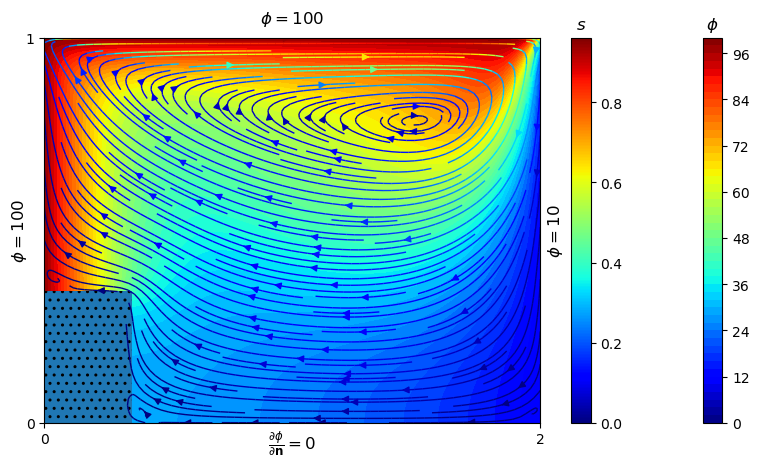

In [144]:
#g.solve('\phi')
n2.plot('\\phi', levels=50, streamlines=2)

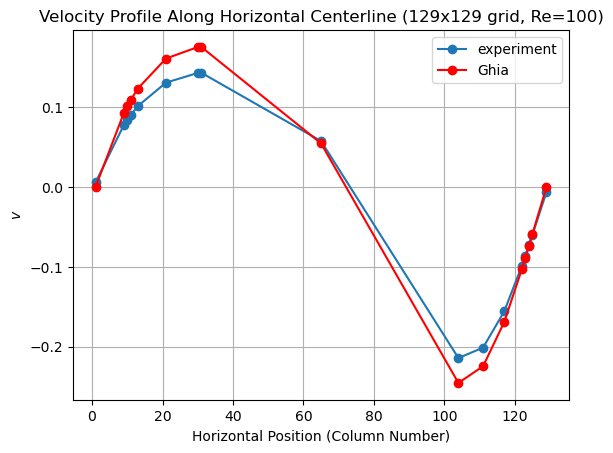

In [1045]:
center_row = len(s2.x['v']) // 2
x = np.array([1,9,10,11,13,21,30,31,65,104,111,117,122,123,124,125,129]) 
vref = np.array([
0.00000,
-0.05906,
-0.07391,
-0.08864,
-0.10313,
-0.16914,
-0.22445,
-0.24533,
0.05454,
0.17527,
0.17507,
0.16077,
0.12317,
0.10890,
0.10091,
0.09233,
0.00000 ])[::-1]
velocity_profile = s2.x['v'][center_row, x]

# Plot the velocity profile
plt.plot(x, velocity_profile, marker='o', label="experiment")  
plt.plot(x, vref, marker="o", color='r', label = "Ghia")

plt.title("Velocity Profile Along Horizontal Centerline (129x129 grid, Re=100)")
plt.xlabel("Horizontal Position (Column Number)")
plt.ylabel("$v$")
plt.grid()
plt.legend()
plt.show()

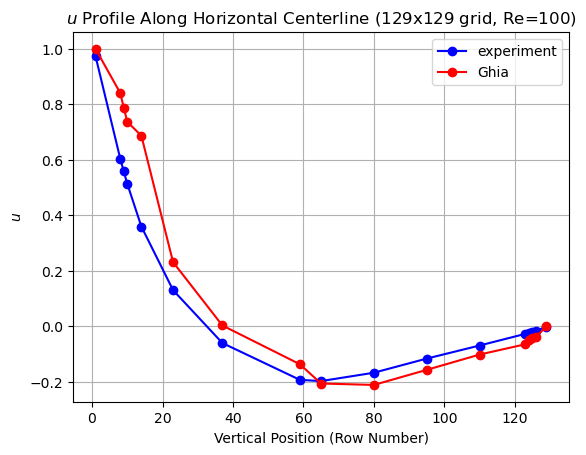

In [1019]:
rows = np.array([1,8,9,10,14,23,37,59,65,80,95,110,123,124,125,126,129])[::-1]
uref = np.array([1.00000,
0.84123,
0.78871,
0.73722,
0.68717,
0.23151,
0.00332,
-0.13641,
-0.20581,
-0.21090,
-0.15662,
-0.10150,
-0.06434,
-0.04775,
-0.04192,
-0.03717,
0.00000])[::-1]

center_col = (s2.n_rows + 2 ) // 2
x = np.arange(1, s2.n_rows+1) if rows is None else rows

velocity_profile = s2.x['u'][x, center_col]

plt.plot(x, velocity_profile, marker='o', color='b', label="experiment")  

if uref is not None:
    assert(len(uref) == len(rows))
    plt.plot(x, uref, marker="o", color='r', label = 'Ghia')

plt.title(f"$u$ Profile Along Horizontal Centerline ({s2.n_rows}x{s2.n_cols} grid, Re={s2.Re})")
plt.xlabel(f"Vertical Position (Row Number)")
plt.ylabel(f"$u$")
plt.grid()
plt.legend()
plt.show()

In [115]:

n3 = NavierStokesSolver(n_rows=100, n_cols=100,gamma=0.1, u=(1,1), phi_B = (10, 100, 100, None), scheme='central_difference')
n3.dirichlet_bnd['\\phi']['s'][-1, :] = False
n3.neumann_bnd['\\phi']['s'][-1, :] = True
n3.solve(threshold=1e-4)


(array([100.   , 100.   , 100.   , ...,  30.011,  22.643,  14.5  ]),
 0.0007109361988062037)

In [116]:
n3.x['u']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 1., 0.],
       ...,
       [0., 1., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

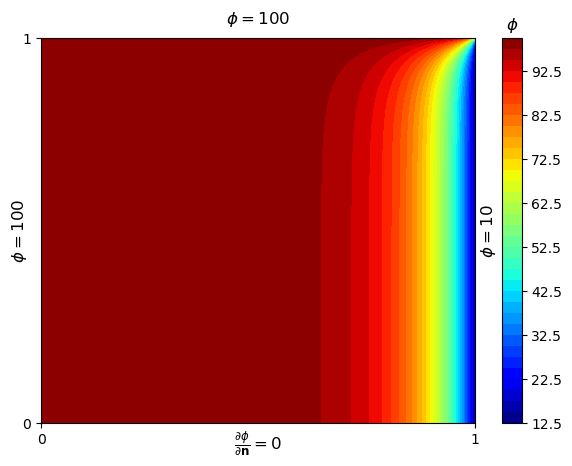

In [118]:
n3.plot('\\phi', streamlines=0)

In [44]:
n4 = NavierStokesSolver(L=1, gamma=0.1, phi_Bs=60, Re=100, 
                          obstacle_coords=[((14/30,0/30), (16/30,30/30))], 
                          n_cols=200, n_rows=200, 
                          scheme='central_difference',
                          u=(
                              lambda x, y:  0.4 if x < 0.5 else 0 if np.linalg.norm(np.array([x, y]) - np.array([3/4, 3/4])) > 0.2 else 25*(y-3/4), 
                              lambda x, y: 1 if x < 0.5 else 0 if np.linalg.norm(np.array([x, y]) - np.array([3/4, 3/4])) > 0.2 else -25*(x - 3/4)))
n4.solve('\\phi')

(array([100.003, 100.009, 100.015, ...,  51.972,  46.394,  30.   ]),
 0.0014283760500642395)

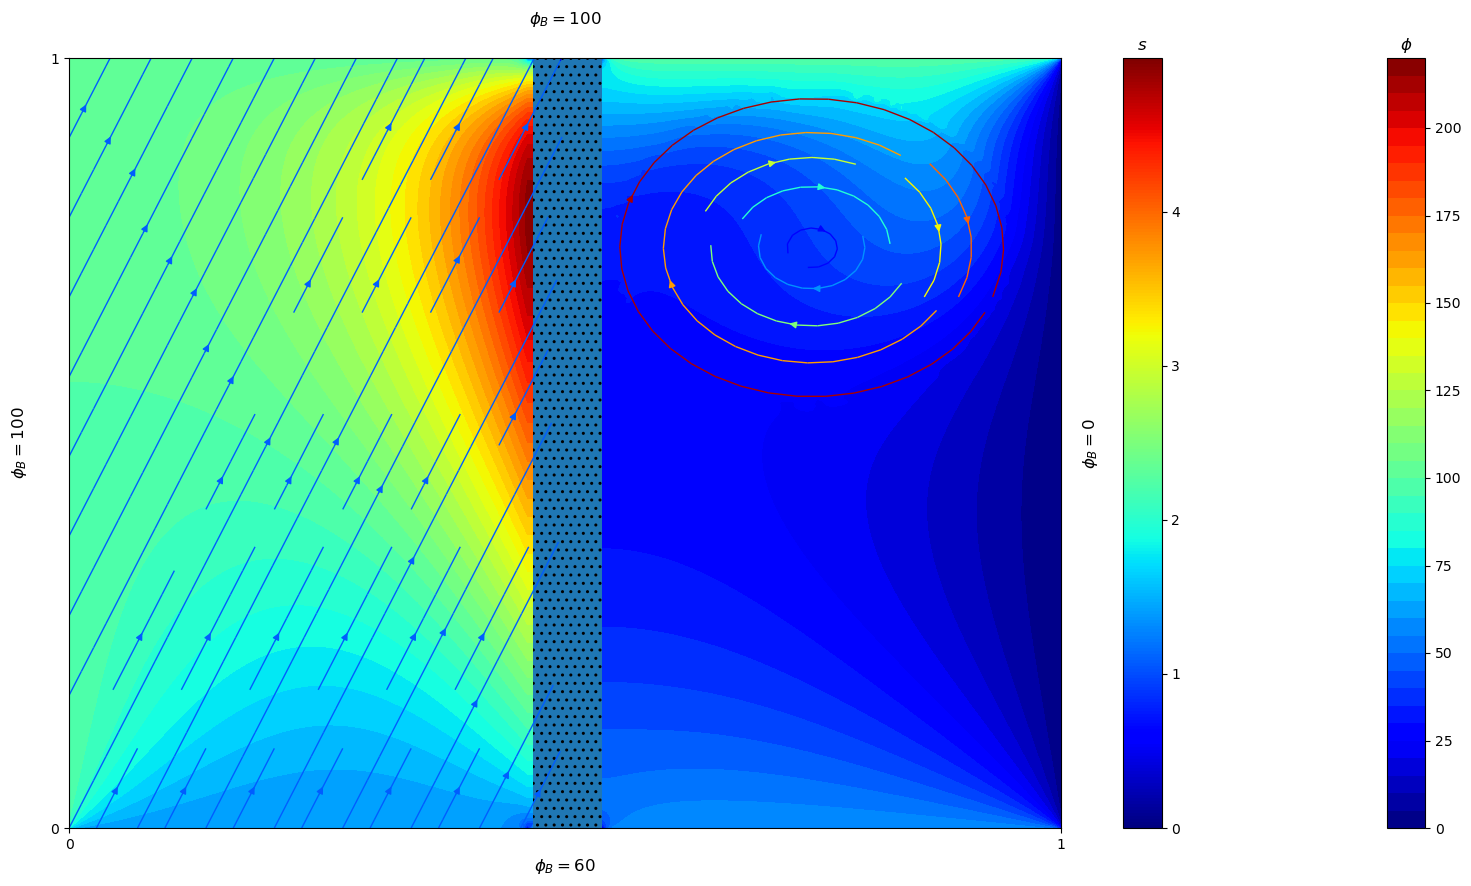

In [45]:

n4.plot('\phi', levels=50, streamlines=1, figsize=10)

In [312]:
n4 = NavierStokesSolver(scheme='central_difference', L_x=2, L_y=1/4, u_B=(None,1,0,0), v_B=(None, 0,0,0), n_rows=10, n_cols=10)



In [315]:
with np.printoptions(threshold=np.inf, suppress=False): print(n4.x['p'])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [313]:
n4.solve('m', threshold=1e-5)

C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:796: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e, (1/2) * (self._area_('e') / a_e + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:797: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w, (1/2) * (self._area_('w') / a_w + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:798: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n, (1/2) * (self._area_('n') / a_n + d_py), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:799: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s, (1/2) * (self._area_('s') / a_s + d_py), 0)


KeyboardInterrupt: 

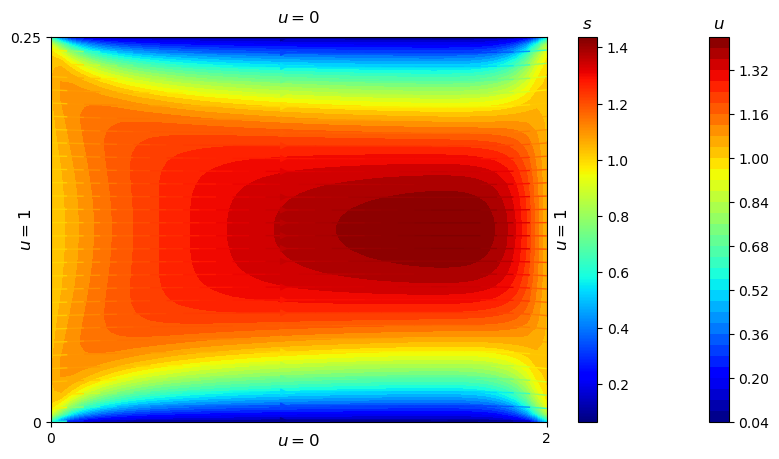

In [250]:
n4.plot('u', streamlines=1)

In [252]:
L = 1

In [285]:
n5 = NavierStokesSolver(scheme='central_difference', L_x=2 * L, L_y=L/4, u_B=(1/2,1,0,0), v_B=(0, 0,0,0), obstacle_coords=[((0,0), (L, L/8))], n_rows=10, n_cols=10)

In [286]:
n5.solve('m', threshold=1e-4)

C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:796: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e, (1/2) * (self._area_('e') / a_e + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:797: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w, (1/2) * (self._area_('w') / a_w + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:798: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n, (1/2) * (self._area_('n') / a_n + d_py), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17476\1189544592.py:799: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s, (1/2) * (self._area_('s') / a_s + d_py), 0)


KeyboardInterrupt: 